In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

READING THE DATASET


In [45]:
df = pd.read_csv('titanic_messy.csv')

RUNNING CORE INSPECTIONS

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  906 non-null    int64  
 1   Survived     906 non-null    int64  
 2   Pclass       906 non-null    int64  
 3   Name         906 non-null    object 
 4   Sex          906 non-null    object 
 5   Age          726 non-null    float64
 6   SibSp        906 non-null    int64  
 7   Parch        906 non-null    int64  
 8   Ticket       906 non-null    object 
 9   Fare         906 non-null    object 
 10  Cabin        224 non-null    object 
 11  Embarked     904 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 85.1+ KB


In [47]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch
count,906.000000,906.000000,906.000000,726.000000,906.000000,906.000000
mean,445.166667,0.385210,2.310155,30.256433,0.523179,0.380795
std,257.120669,0.486914,0.835567,23.315838,1.099479,0.803051
min,1.000000,0.000000,1.000000,-62.000000,0.000000,0.000000
25%,223.250000,0.000000,2.000000,20.000000,0.000000,0.000000
50%,443.500000,0.000000,3.000000,28.000000,0.000000,0.000000
75%,668.750000,1.000000,3.000000,38.000000,1.000000,0.000000
max,891.000000,1.000000,3.000000,300.000000,8.000000,6.000000


In [48]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,180
SibSp,0
Parch,0
Ticket,0
Fare,0


In [49]:
df.isnull().sum() / len(df) * 100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.867550
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


<Axes: xlabel='Age', ylabel='Count'>

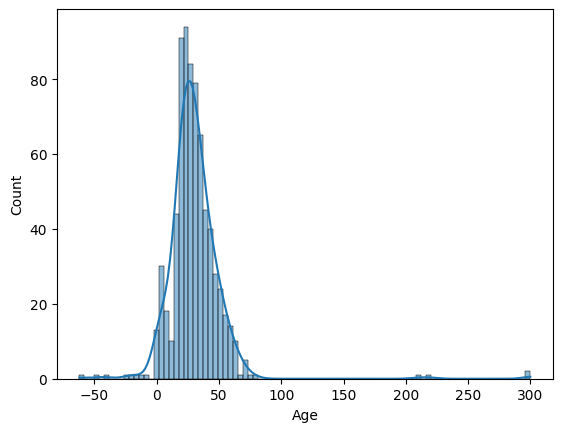

In [50]:
sns.histplot(df['Age'],kde=True)

<Axes: xlabel='Fare', ylabel='Count'>

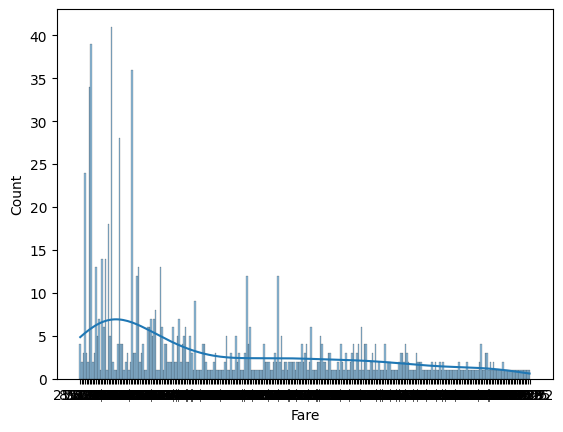

In [51]:
sns.histplot(df['Fare'],kde=True)

In [52]:
# Calculate survival rate by Sex
print("Survival Rate by Sex:")
print(df.groupby('Sex')['Survived'].mean())

# Calculate survival rate by Ticket Class (Pclass)
print("\nSurvival Rate by Pclass:")
print(df.groupby('Pclass')['Survived'].mean())

Survival Rate by Sex:
Sex
 female     0.784946
 male       0.195122
FEMALE      0.741176
Female      0.771429
MALE        0.185185
Male        0.142857
female      0.671233
male        0.225000
Name: Survived, dtype: float64

Survival Rate by Pclass:
Pclass
1    0.630137
2    0.470588
3    0.246000
Name: Survived, dtype: float64


In [53]:
# Create the Age_bin column
df['Age_bin'] = pd.cut(df['Age'], bins=[0, 12, 18, 60, 100], labels=['Child', 'Teen', 'Adult', 'Senior'])

# Calculate survival rate by the new Age_bin column
print("\nSurvival Rate by Age Group:")
print(df.groupby('Age_bin')['Survived'].mean())


Survival Rate by Age Group:
Age_bin
Child     0.594203
Teen      0.422535
Adult     0.386980
Senior    0.190476
Name: Survived, dtype: float64


/tmp/ipykernel_1002/755691955.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Age_bin')['Survived'].mean())


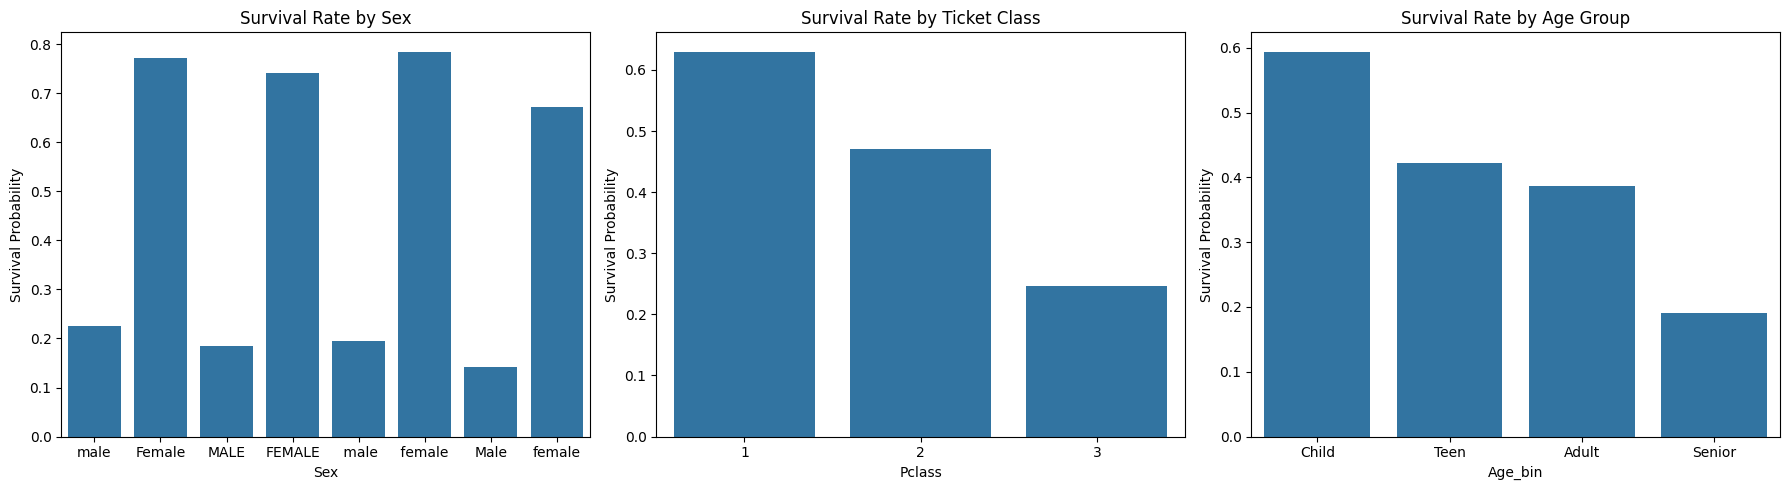

In [54]:
# Set up a grid for 3 side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Survival by Sex
sns.barplot(data=df, x='Sex', y='Survived', ax=axes[0], errorbar=None)
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Probability')

# Plot 2: Survival by Pclass
sns.barplot(data=df, x='Pclass', y='Survived', ax=axes[1], errorbar=None)
axes[1].set_title('Survival Rate by Ticket Class')
axes[1].set_ylabel('Survival Probability')

# Plot 3: Survival by Age_bin
sns.barplot(data=df, x='Age_bin', y='Survived', ax=axes[2], errorbar=None)
axes[2].set_title('Survival Rate by Age Group')
axes[2].set_ylabel('Survival Probability')

# Adjust layout so labels don't overlap and display the charts
plt.tight_layout()
plt.show()

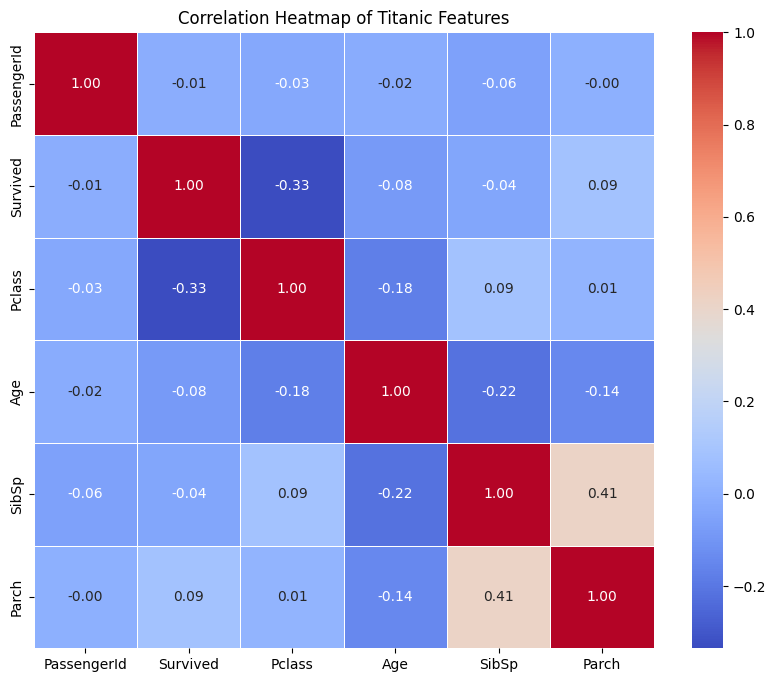

In [55]:
# Create a correlation matrix using only numerical columns
corr_matrix = df.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Titanic Features')
plt.show()

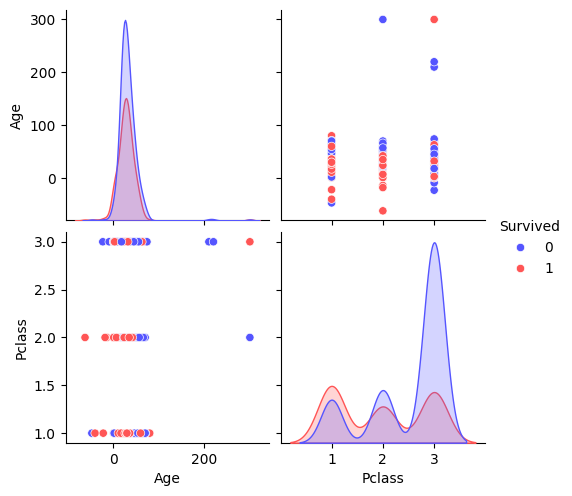

In [56]:
# Plot feature interactions color-coded by Survival
# We pass a subset of columns so the grid doesn't become too cluttered
sns.pairplot(df[['Age', 'Fare', 'Pclass', 'Survived']], hue='Survived', palette='seismic')
plt.show()

Observation 1: Passengers in 1st class had a dramatically higher survival rate than those in 3rd class, suggesting evacuation priority was based on ticket class.

Observation 2: The correlation heatmap shows a negative correlation between Pclass and Fare (which makes sense, as 1st class is a lower number but a higher price).

Observation 3: The survival rate for females was overwhelmingly higher than for males across all ticket classes.